### 08-01 Fashion Classification

### 08-02 TensorFlow and Keras

In [12]:
import tensorflow as tf
from tensorflow import keras

import numpy as np

In [2]:
from tensorflow.keras.preprocessing.image import load_img

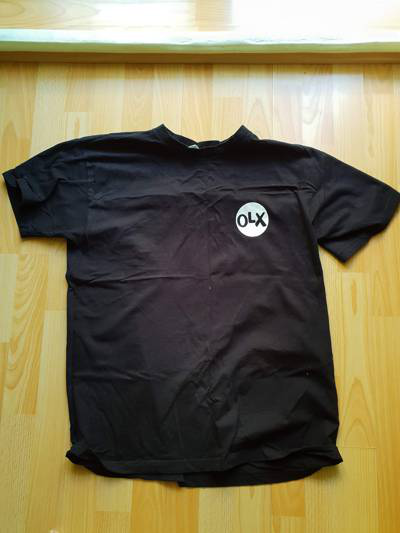

In [6]:
path = '../clothing-dataset-small/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'

load_img(fullname)

In [47]:
img = load_img(fullname, target_size=(2, 4))

In [48]:
print(img)

<PIL.Image.Image image mode=RGB size=4x2 at 0x194633830>


In [49]:
x = np.array(img) # each row is R, G, B
x

array([[[208, 204, 166],
        [ 45,  47,  59],
        [ 70,  72,  67],
        [232, 221, 189]],

       [[190, 174,  97],
        [ 23,  23,  25],
        [ 33,  33,  33],
        [195, 171,  71]]], dtype=uint8)

In [50]:
x.shape

(2, 4, 3)

In [51]:
x[0]

array([[208, 204, 166],
       [ 45,  47,  59],
       [ 70,  72,  67],
       [232, 221, 189]], dtype=uint8)

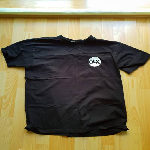

In [52]:
load_img(fullname, target_size=(150, 150))

In [59]:
img = load_img(fullname, target_size=(299, 299))
x = np.array(img) # each row is R, G, B
x

array([[[179, 171,  99],
        [179, 171,  99],
        [181, 173, 101],
        ...,
        [251, 253, 248],
        [251, 253, 248],
        [251, 253, 248]],

       [[188, 179, 110],
        [187, 178, 109],
        [186, 177, 108],
        ...,
        [251, 252, 247],
        [251, 252, 247],
        [251, 252, 246]],

       [[199, 189, 127],
        [200, 190, 128],
        [200, 190, 128],
        ...,
        [250, 251, 245],
        [250, 251, 245],
        [250, 251, 245]],

       ...,

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [183, 135,  24],
        [181, 133,  22],
        [183, 135,  24]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [182, 134,  23],
        [180, 132,  21],
        [182, 134,  23]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [181, 133,  22],
        [179, 131,  20],
        [182, 134,  23]]

In [60]:
x.shape

(299, 299, 3)

### 08-03 Pretrained models

In [76]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [62]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [69]:
X = np.array([x])

In [70]:
X.shape

(1, 299, 299, 3)

In [71]:
X = preprocess_input(X)

In [72]:
X

array([[[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.41960788,  0.35686278, -0.20784312],
         ...,
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.9843137 ,  0.94509804]],

        [[ 0.47450984,  0.4039216 , -0.1372549 ],
         [ 0.4666667 ,  0.39607847, -0.14509803],
         [ 0.45882356,  0.38823533, -0.15294117],
         ...,
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.92941177]],

        [[ 0.56078434,  0.48235297, -0.00392157],
         [ 0.5686275 ,  0.4901961 ,  0.00392163],
         [ 0.5686275 ,  0.4901961 ,  0.00392163],
         ...,
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863]],

        ...,

        [[ 0.2941177 ,  0.18431377, -0

In [74]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


In [75]:
pred.shape

(1, 1000)

In [77]:
decode_predictions(pred)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n03595614', 'jersey', 0.6792446),
  ('n02916936', 'bulletproof_vest', 0.039600324),
  ('n04370456', 'sweatshirt', 0.035299607),
  ('n03710637', 'maillot', 0.010884145),
  ('n04525038', 'velvet', 0.0018057632)]]

### 08-04 Convolutional Neural Networks

- Mainly ised for images
- Consists of convolutional layers and dense layers
<br>
<br>
- Convolutional layers
  - consist of filters which are small images or lines, curves, etc.
  - feature map is the similarity result of sliding one filter across the whole image
  - => Output of the first convolutional layer is a set of feature maps
  - Pooling can be applied to shrink the feature map
  - The feature maps can be interpreted as a new image
  - This image is then passed to the next convolutional layer
  - 1st convolutional layer recognises simple patterns, following convolutinoal layers detect more complex shapes
  - Result of convolutional layers is a vector representation (for ex: 2048) of the image.
- Dense layers
  - Take the vector representation and make the prediction
  - Sigmoid for binary classification
  - softmax for multiclass classification
  - model
  - is nothing more than matrix multiplication
  - inner dense layer and final dense layer
  



### O8-05 Transfer Learning

In [78]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [79]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
# preprocess_input is the one imported from xception

In [ ]:
train_ds = train_gen.flow_from_directory(
    '../clothing-dataset-small/train', 
    target_size=(150, 150), 
    batch_size=32 # => 32 images => 32 vector representations
)

Found 3068 images belonging to 10 classes.


In [82]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [85]:
ls -l ../clothing-dataset-small/train

total 0
drwxr-xr-x@ 243 frederic  staff   7776 Sep 10 15:39 dress/
drwxr-xr-x@ 125 frederic  staff   4000 Sep 10 15:39 hat/
drwxr-xr-x@ 457 frederic  staff  14624 Sep 10 15:39 longsleeve/
drwxr-xr-x@ 186 frederic  staff   5952 Sep 10 15:39 outwear/
drwxr-xr-x@ 470 frederic  staff  15040 Sep 10 15:39 pants/
drwxr-xr-x@ 292 frederic  staff   9344 Sep 10 15:39 shirt/
drwxr-xr-x@ 200 frederic  staff   6400 Sep 10 15:39 shoes/
drwxr-xr-x@ 204 frederic  staff   6528 Sep 10 15:39 shorts/
drwxr-xr-x@ 114 frederic  staff   3648 Sep 10 15:39 skirt/
drwxr-xr-x@ 797 frederic  staff  25504 Sep 10 15:39 t-shirt/


In [86]:
X, y = next(train_ds)

In [87]:
X

array([[[[ 0.8901961 ,  0.8745098 ,  0.8980392 ],
         [ 0.56078434,  0.54509807,  0.5686275 ],
         [ 0.3803922 ,  0.36470592,  0.38823533],
         ...,
         [ 0.6392157 ,  0.6392157 ,  0.654902  ],
         [ 0.6392157 ,  0.6392157 ,  0.654902  ],
         [ 0.6392157 ,  0.6392157 ,  0.654902  ]],

        [[-0.09803921, -0.11372548, -0.09019607],
         [ 0.5137255 ,  0.49803925,  0.52156866],
         [ 0.7254902 ,  0.70980394,  0.73333335],
         ...,
         [ 0.654902  ,  0.654902  ,  0.67058825],
         [ 0.654902  ,  0.654902  ,  0.67058825],
         [ 0.654902  ,  0.654902  ,  0.67058825]],

        [[-0.09803921, -0.11372548, -0.09019607],
         [-0.12156862, -0.1372549 , -0.11372548],
         [-0.10588235, -0.12156862, -0.09803921],
         ...,
         [ 0.6784314 ,  0.6784314 ,  0.69411767],
         [ 0.67058825,  0.67058825,  0.6862745 ],
         [ 0.6627451 ,  0.6627451 ,  0.6784314 ]],

        ...,

        [[-0.30196077, -0.3098039 , -0

In [88]:
X.shape

(32, 150, 150, 3)

In [89]:
y[:5]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [91]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '../clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [92]:
base_model = Xception(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3)
)
# include_top=False because in Keras bottom is the convolutional layers and top are the dense layers and prediction

base_model.trainable = False # => Freeze convolutional layers

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [111]:
# Creating new top
inputs = keras.Input(shape=(150, 150, 3)) # Image of shirt

base = base_model(inputs, training=False) # 3D long thing

# 1D
vectors = keras.layers.GlobalAveragePooling2D()(base) # Functional style
# instead of
# pooling = keras.layers.GlobalAveragePooling2D()
# vectors = pooling(base)

# When we create the Dense layers, it is initialised with random numbers
outputs = keras.layers.Dense(10)(vectors) # 10 classes and the inputs are vectors

model = keras.Model(inputs, outputs)

In [112]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [113]:
preds.shape

(32, 10)

In [114]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True) 
# Logits are the raw outputs of the dense layer before applying 
# any activation. Else, if False, then in keras.layers.dense(10,
# activation='softmax)(vectors)

# For multiclass classification, use CategoricalCrossentropy
# For binary classfication, use BinaryCrossentropy
# For regrssion problem, use MeanSquaredError

In [115]:
# Compile the model before training
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [116]:
# Dataset is in batches, for ex: 32, 32, ..., 32, 17
# 1 iteration on the whole dataset (no matter the batch size) is 1 epoch
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.6548 - loss: 1.2940 - val_accuracy: 0.7625 - val_loss: 0.9219
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8184 - loss: 0.5837 - val_accuracy: 0.8006 - val_loss: 0.7881
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.8742 - loss: 0.3676 - val_accuracy: 0.7507 - val_loss: 0.9248
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9081 - loss: 0.2536 - val_accuracy: 0.7742 - val_loss: 0.9393
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.9358 - loss: 0.1801 - val_accuracy: 0.7742 - val_loss: 1.1390
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9580 - loss: 0.1278 - val_accuracy: 0.8094 - val_loss: 0.9273
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9694 - loss: 0.0883 - val_accuracy: 0.8035 - val_loss: 0.8965
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.9824 - loss: 0.0532 - val_accuracy: 0.8123 - v

In [117]:
history

In [118]:
history.history

{'accuracy': [0.6548240184783936,
  0.8184484839439392,
  0.8741851449012756,
  0.908083438873291,
  0.9357888102531433,
  0.9579530358314514,
  0.9693611264228821,
  0.9823989272117615,
  0.9859843254089355,
  0.9947848916053772],
 'loss': [1.2939988374710083,
  0.5837392807006836,
  0.36762791872024536,
  0.25357919931411743,
  0.18014919757843018,
  0.1277679055929184,
  0.08831624686717987,
  0.05320505425333977,
  0.04955809935927391,
  0.02814563922584057],
 'val_accuracy': [0.7624633312225342,
  0.8005865216255188,
  0.7507331371307373,
  0.774193525314331,
  0.774193525314331,
  0.8093841671943665,
  0.803519070148468,
  0.8123167157173157,
  0.8123167157173157,
  0.8005865216255188],
 'val_loss': [0.9218612909317017,
  0.7881089448928833,
  0.9247772097587585,
  0.9392580986022949,
  1.1389915943145752,
  0.927338719367981,
  0.8964855670928955,
  0.9342620968818665,
  0.9881493449211121,
  0.9668416380882263]}

In [119]:
history.history['accuracy']

[0.6548240184783936,
 0.8184484839439392,
 0.8741851449012756,
 0.908083438873291,
 0.9357888102531433,
 0.9579530358314514,
 0.9693611264228821,
 0.9823989272117615,
 0.9859843254089355,
 0.9947848916053772]

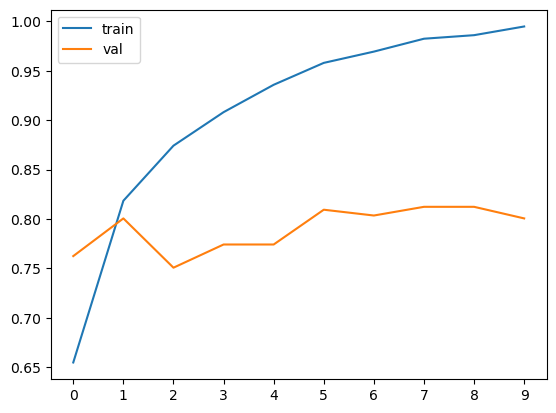

In [129]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))

plt.legend()

### 08-06 Leanring rate

In [130]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet', 
        include_top=False, 
        input_shape=(150, 150, 3)
    )
    # include_top=False because in Keras bottom is the convolutional layers and top are the dense layers and prediction

    base_model.trainable = False # => Freeze convolutional layers

    ##################################################

    # Creating new top
    inputs = keras.Input(shape=(150, 150, 3)) # Image of shirt

    base = base_model(inputs, training=False) # 3D long thing

    # 1D
    vectors = keras.layers.GlobalAveragePooling2D()(base) # Functional style
    # instead of
    # pooling = keras.layers.GlobalAveragePooling2D()
    # vectors = pooling(base)

    # When we create the Dense layers, it is initialised with random numbers
    outputs = keras.layers.Dense(10)(vectors) # 10 classes and the inputs are vectors

    model = keras.Model(inputs, outputs)
    
    ####################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    loss = keras.losses.CategoricalCrossentropy(from_logits=True) 
    # Logits are the raw outputs of the dense layer before applying 
    # any activation. Else, if False, then in keras.layers.dense(10,
    # activation='softmax)(vectors)

    # For multiclass classification, use CategoricalCrossentropy
    # For binary classfication, use BinaryCrossentropy
    # For regrssion problem, use MeanSquaredError

    # Compile the model before training
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    return model

In [131]:
scores = {}
for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    # Dataset is in batches, for ex: 32, 32, ..., 32, 17
    # 1 iteration on the whole dataset (no matter the batch size) is 1 epoch
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.3804 - loss: 1.8735 - val_accuracy: 0.4927 - val_loss: 1.5749
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.5724 - loss: 1.3703 - val_accuracy: 0.6129 - val_loss: 1.2466
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.6483 - loss: 1.1377 - val_accuracy: 0.6804 - val_loss: 1.0730
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.6897 - loss: 1.0006 - val_accuracy: 0.7067 - val_loss: 0.9596
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7099 - loss: 0.9099 - val_accuracy: 0.7361 - val_loss: 0.8843
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7344 - loss: 0.8409 - val_accuracy: 0.7478 - val_loss: 0.8342
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.7503 - loss: 0.7894 - val_accuracy: 0.7390 - val_loss: 0.7929
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.7627 - loss: 0.7478 - val_accuracy: 0.7

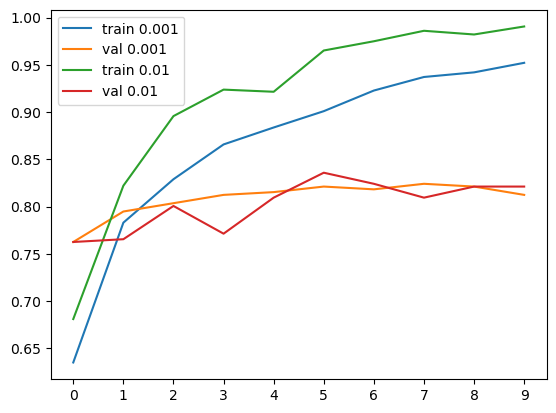

In [136]:
for lr, hist in scores.items():
    if lr in [0.01, 0.001]:
        plt.plot(hist['accuracy'], label=f"train {lr}")
        plt.plot(hist['val_accuracy'], label=f"val {lr}")

plt.xticks(np.arange(10))
plt.legend()

In [137]:
learning_rate = 0.001

### 08-07 Checkpointing

In [ ]:
model.save_weights('model_v1.h5', save_format='h5')

ValueError: The filename must end in `.weights.h5`. Received: filepath=model_v1.h5

In [140]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [141]:
learning_rate = 0.001

model = make_model(learning_rate=learning_rate)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5199 - loss: 1.4582

96/96 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.6340 - loss: 1.0936 - val_accuracy: 0.7537 - val_loss: 0.7301
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7827 - loss: 0.6443

96/96 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.7826 - loss: 0.6286 - val_accuracy: 0.8094 - val_loss: 0.6177
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8382 - loss: 0.5069

96/96 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.8269 - loss: 0.5110 - val_accuracy: 0.8123 - val_loss: 0.5988
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8579 - loss: 0.4434

96/96 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.8618 - loss: 0.4298 - val_accuracy: 0.8211 - val_loss: 0.5534
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8856 - loss: 0.3744 - val_accuracy: 0.8006 - val_loss: 0.5556
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9173 - loss: 0.3132

96/96 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.9074 - loss: 0.3269 - val_accuracy: 0.8240 - val_loss: 0.5410
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9297 - loss: 0.2817

96/96 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.9260 - loss: 0.2889 - val_accuracy: 0.8299 - val_loss: 0.5224
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9343 - loss: 0.2561

96/96 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.9316 - loss: 0.2585 - val_accuracy: 0.8446 - val_loss: 0.5345
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9426 - loss: 0.2335 - val_accuracy: 0.8270 - val_loss: 0.5210
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.9511 - loss: 0.2144 - val_accuracy: 0.8182 - val_loss: 0.5340


### 08-08 Adding one extra layer

In [144]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet', 
        include_top=False, 
        input_shape=(150, 150, 3)
    )
    # include_top=False because in Keras bottom is the convolutional layers and top are the dense layers and prediction

    base_model.trainable = False # => Freeze convolutional layers

    ##################################################

    # Creating new top
    inputs = keras.Input(shape=(150, 150, 3)) # Image of shirt

    base = base_model(inputs, training=False) # 3D long thing

    # 1D
    vectors = keras.layers.GlobalAveragePooling2D()(base) # Functional style
    # instead of
    # pooling = keras.layers.GlobalAveragePooling2D()
    # vectors = pooling(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    # When we create the Dense layers, it is initialised with random numbers
    outputs = keras.layers.Dense(10)(inner) # 10 classes and the inputs are vectors

    model = keras.Model(inputs, outputs)
    
    ####################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    loss = keras.losses.CategoricalCrossentropy(from_logits=True) 
    # Logits are the raw outputs of the dense layer before applying 
    # any activation. Else, if False, then in keras.layers.dense(10,
    # activation='softmax)(vectors)

    # For multiclass classification, use CategoricalCrossentropy
    # For binary classfication, use BinaryCrossentropy
    # For regrssion problem, use MeanSquaredError

    # Compile the model before training
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    return model

In [143]:
# sigmoid, softmax for output dense layer
# ReLU, ... for intermediate dense layers

In [145]:
learning_rate = 0.001

scores = {}
for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    # Dataset is in batches, for ex: 32, 32, ..., 32, 17
    # 1 iteration on the whole dataset (no matter the batch size) is 1 epoch
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.3954 - loss: 1.6864 - val_accuracy: 0.5924 - val_loss: 1.1896
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.6235 - loss: 1.1178 - val_accuracy: 0.6804 - val_loss: 0.9875
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.6904 - loss: 0.9304 - val_accuracy: 0.7038 - val_loss: 0.8977
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.7308 - loss: 0.8150 - val_accuracy: 0.7449 - val_loss: 0.8300
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.7634 - loss: 0.7247 - val_accuracy: 0.7361 - val_loss: 0.7796
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.7855 - loss: 0.6557 - val_accuracy: 0.7625 - val_loss: 0.7601
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.8090 - loss: 0.5975 - val_accuracy: 0.7478 - val_loss: 0.7513
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.8325 - loss: 0.5487 - val_accuracy: 0.7537 

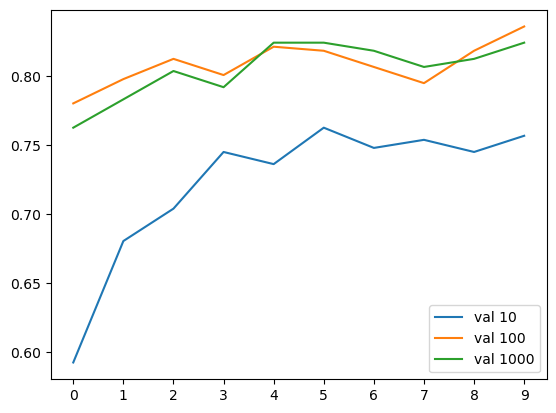

In [146]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f"val {size}")

plt.xticks(np.arange(10))
plt.legend()

We can add more layers between the vector representation and the output layer. These are the same dense layers as the output layer - the difference is that intermediate layers use an activation function for non-linearity. Without it, stacking dense layers wouldn't help: several linear transformations in a row collapse into one linear transformation.

### 08-09 Regularization and Dropout

In [147]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet', 
        include_top=False, 
        input_shape=(150, 150, 3)
    )
    # include_top=False because in Keras bottom is the convolutional layers and top are the dense layers and prediction

    base_model.trainable = False # => Freeze convolutional layers

    ##################################################

    # Creating new top
    inputs = keras.Input(shape=(150, 150, 3)) # Image of shirt

    base = base_model(inputs, training=False) # 3D long thing

    # 1D
    vectors = keras.layers.GlobalAveragePooling2D()(base) # Functional style
    # instead of
    # pooling = keras.layers.GlobalAveragePooling2D()
    # vectors = pooling(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    # When we create the Dense layers, it is initialised with random numbers
    outputs = keras.layers.Dense(10)(drop) # 10 classes and the inputs are vectors

    model = keras.Model(inputs, outputs)
    
    ####################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    loss = keras.losses.CategoricalCrossentropy(from_logits=True) 
    # Logits are the raw outputs of the dense layer before applying 
    # any activation. Else, if False, then in keras.layers.dense(10,
    # activation='softmax)(vectors)

    # For multiclass classification, use CategoricalCrossentropy
    # For binary classfication, use BinaryCrossentropy
    # For regrssion problem, use MeanSquaredError

    # Compile the model before training
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    return model

In [149]:
learning_rate = 0.001
size = 100

scores = {}
for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(
        learning_rate=learning_rate, 
        size_inner=size,
        droprate=droprate
    )
    # Dataset is in batches, for ex: 32, 32, ..., 32, 17
    # 1 iteration on the whole dataset (no matter the batch size) is 1 epoch
    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.6832 - loss: 0.9376 - val_accuracy: 0.7977 - val_loss: 0.6203
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.8328 - loss: 0.4900 - val_accuracy: 0.8065 - val_loss: 0.5810
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.8898 - loss: 0.3387 - val_accuracy: 0.8006 - val_loss: 0.6127
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.9280 - loss: 0.2350 - val_accuracy: 0.8035 - val_loss: 0.6181
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9599 - loss: 0.1613 - val_accuracy: 0.8065 - val_loss: 0.5978
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.9772 - loss: 0.1105 - val_accuracy: 0.7918 - val_loss: 0.6551
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9905 - loss: 0.0739 - val_accuracy: 0.8065 - val_loss: 0.6454
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9909 - loss: 0.0591 - val_accuracy: 0.8065

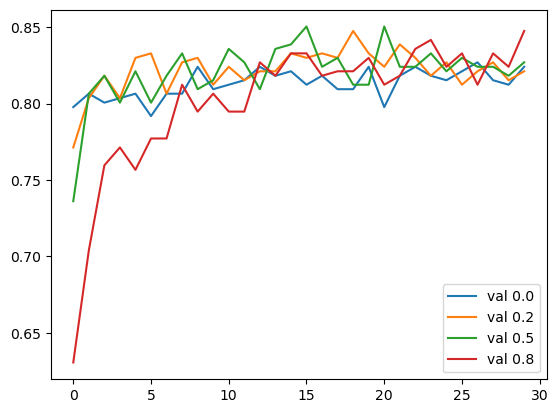

In [ ]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f"val {droprate}")

plt.legend()

Dropout addresses this by hiding a random part of the network at each iteration - not the image itself, but the input to the inner dense layer.

Dropout doesn't change the dimensionality of the layer - it only temporarily zeros out parts of it while training.

Dropout is a technique that prevents overfitting in neural networks by randomly dropping nodes of a layer during training. As a result, the trained model works as an ensemble model consisting of multiple neural networks.



Note: Because we introduce dropout in the neural networks, we will need to train our model for longer, hence, number of epochs is set to 30.

### 08-10 Data augmentation

In [155]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    #rotation_range=30, # => [-30, 30]
    #width_shift_range=10.0,
    #height_shift_range=10.0,
    shear_range=10.0,
    zoom_range=0.1,
    #cval=0.0,
    #horizontal_flip=False,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    '../clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '../clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [156]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate=learning_rate, 
    size_inner=size,
    droprate=droprate
)
# Dataset is in batches, for ex: 32, 32, ..., 32, 17
# 1 iteration on the whole dataset (no matter the batch size) is 1 epoch
history = model.fit(train_ds, epochs=50, validation_data=val_ds)


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.5655 - loss: 1.3057 - val_accuracy: 0.7595 - val_loss: 0.7585
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.7005 - loss: 0.8932 - val_accuracy: 0.7449 - val_loss: 0.7038
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.7370 - loss: 0.7739 - val_accuracy: 0.7830 - val_loss: 0.6445
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.7591 - loss: 0.7129 - val_accuracy: 0.7918 - val_loss: 0.6225
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.7702 - loss: 0.6477 - val_accuracy: 0.7859 - val_loss: 0.6086
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7920 - loss: 0.6041 - val_accuracy: 0.8152 - val_loss: 0.5964
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.8093 - loss: 0.5673 - val_accuracy: 0.7830 - val_loss: 0.6060
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8230 - loss: 0.5282 - val_accuracy: 0.8006 - v

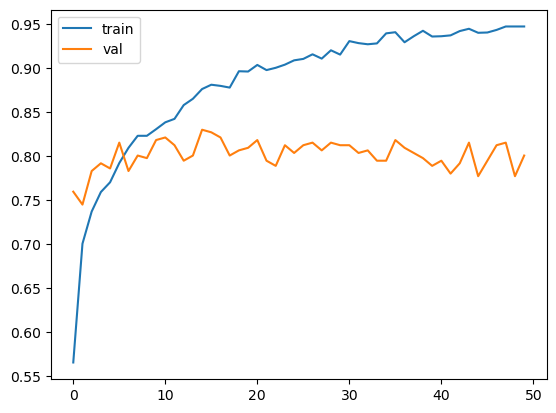

In [160]:
plt.plot(history.history['accuracy'], label=f"train")
plt.plot(history.history['val_accuracy'], label=f"val")


plt.legend()

### 08-11 Larger models

In [161]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet', 
        include_top=False, 
        input_shape=(input_size, input_size, 3)
    )
    # include_top=False because in Keras bottom is the convolutional layers and top are the dense layers and prediction

    base_model.trainable = False # => Freeze convolutional layers

    ##################################################

    # Creating new top
    inputs = keras.Input(shape=(input_size, input_size, 3)) # Image of shirt

    base = base_model(inputs, training=False) # 3D long thing

    # 1D
    vectors = keras.layers.GlobalAveragePooling2D()(base) # Functional style
    # instead of
    # pooling = keras.layers.GlobalAveragePooling2D()
    # vectors = pooling(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    # When we create the Dense layers, it is initialised with random numbers
    outputs = keras.layers.Dense(10)(drop) # 10 classes and the inputs are vectors

    model = keras.Model(inputs, outputs)
    
    ####################################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    loss = keras.losses.CategoricalCrossentropy(from_logits=True) 
    # Logits are the raw outputs of the dense layer before applying 
    # any activation. Else, if False, then in keras.layers.dense(10,
    # activation='softmax)(vectors)

    # For multiclass classification, use CategoricalCrossentropy
    # For binary classfication, use BinaryCrossentropy
    # For regrssion problem, use MeanSquaredError

    # Compile the model before training
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    return model

In [164]:
input_size=299

In [165]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    #rotation_range=30, # => [-30, 30]
    #width_shift_range=10.0,
    #height_shift_range=10.0,
    shear_range=10.0,
    zoom_range=0.1,
    #cval=0.0,
    horizontal_flip=True,
    #vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    '../clothing-dataset-small/train',
    target_size=(input_size, input_size),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '../clothing-dataset-small/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [166]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [168]:
learning_rate = 0.0005
size = 100
droprate = 0.2


model = make_model(
    learning_rate=learning_rate, 
    size_inner=size,
    droprate=droprate,
    input_size=input_size
)
# Dataset is in batches, for ex: 32, 32, ..., 32, 17
# 1 iteration on the whole dataset (no matter the batch size) is 1 epoch
history = model.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[checkpoint])


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5538 - loss: 1.3873

96/96 ━━━━━━━━━━━━━━━━━━━━ 746s 8s/step - accuracy: 0.6897 - loss: 0.9810 - val_accuracy: 0.8416 - val_loss: 0.5117
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8173 - loss: 0.5530

96/96 ━━━━━━━━━━━━━━━━━━━━ 681s 7s/step - accuracy: 0.8230 - loss: 0.5282 - val_accuracy: 0.8651 - val_loss: 0.4258
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8554 - loss: 0.4260

96/96 ━━━━━━━━━━━━━━━━━━━━ 795s 8s/step - accuracy: 0.8566 - loss: 0.4317 - val_accuracy: 0.8739 - val_loss: 0.3712
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8600 - loss: 0.4312

96/96 ━━━━━━━━━━━━━━━━━━━━ 907s 9s/step - accuracy: 0.8690 - loss: 0.3889 - val_accuracy: 0.8827 - val_loss: 0.3675
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 991s 10s/step - accuracy: 0.8745 - loss: 0.3473 - val_accuracy: 0.8710 - val_loss: 0.3708
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 832s 9s/step - accuracy: 0.8872 - loss: 0.3201 - val_accuracy: 0.8827 - val_loss: 0.3460
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 761s 8s/step - accuracy: 0.8941 - loss: 0.3011 - val_accuracy: 0.8622 - val_loss: 0.3594
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9121 - loss: 0.2665

96/96 ━━━━━━━━━━━━━━━━━━━━ 690s 7s/step - accuracy: 0.9094 - loss: 0.2742 - val_accuracy: 0.8886 - val_loss: 0.3305
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 752s 8s/step - accuracy: 0.9117 - loss: 0.2572 - val_accuracy: 0.8768 - val_loss: 0.3446
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9089 - loss: 0.2534

96/96 ━━━━━━━━━━━━━━━━━━━━ 825s 9s/step - accuracy: 0.9104 - loss: 0.2548 - val_accuracy: 0.8915 - val_loss: 0.3318
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 731s 8s/step - accuracy: 0.9270 - loss: 0.2255 - val_accuracy: 0.8827 - val_loss: 0.3445
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 737s 8s/step - accuracy: 0.9276 - loss: 0.2194 - val_accuracy: 0.8915 - val_loss: 0.3274
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 738s 8s/step - accuracy: 0.9319 - loss: 0.2051 - val_accuracy: 0.8798 - val_loss: 0.3436
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 736s 8s/step - accuracy: 0.9322 - loss: 0.2023 - val_accuracy: 0.8827 - val_loss: 0.3288
Epoch 15/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 724s 8s/step - accuracy: 0.9394 - loss: 0.1849 - val_accuracy: 0.8768 - val_loss: 0.3364
Epoch 16/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 728s 8s/step - accuracy: 0.9407 - loss: 0.1828 - val_accuracy: 0.8886 - val_loss: 0.3417
Epoch 17/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 739s 8s/step - accuracy: 0.9423 - loss: 0.1793 - val_accuracy: 0.8915 - val_l

96/96 ━━━━━━━━━━━━━━━━━━━━ 726s 8s/step - accuracy: 0.9518 - loss: 0.1503 - val_accuracy: 0.8944 - val_loss: 0.3476
Epoch 19/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 746s 8s/step - accuracy: 0.9452 - loss: 0.1613 - val_accuracy: 0.8739 - val_loss: 0.3649
Epoch 20/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 727s 8s/step - accuracy: 0.9557 - loss: 0.1458 - val_accuracy: 0.8886 - val_loss: 0.3559
Epoch 21/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 745s 8s/step - accuracy: 0.9482 - loss: 0.1510 - val_accuracy: 0.8827 - val_loss: 0.3494
Epoch 22/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 732s 8s/step - accuracy: 0.9537 - loss: 0.1374 - val_accuracy: 0.8827 - val_loss: 0.3839
Epoch 23/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 744s 8s/step - accuracy: 0.9531 - loss: 0.1433 - val_accuracy: 0.8798 - val_loss: 0.3706
Epoch 24/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 739s 8s/step - accuracy: 0.9609 - loss: 0.1204 - val_accuracy: 0.8856 - val_loss: 0.3594
Epoch 25/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 738s 8s/step - accuracy: 0.9661 - loss: 0.1131 - val_accuracy: 0.8856 - val_l

KeyboardInterrupt: 

### 08-12 Using the model

In [169]:
import tensorflow as tf
from tensorflow import keras

In [171]:
model = keras.models.load_model('xception_v4_18_0.894.h5')

In [173]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.xception import preprocess_input

In [174]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    '../clothing-dataset-small/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)

Found 372 images belonging to 10 classes.


In [175]:
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 79s 6s/step - accuracy: 0.9032 - loss: 0.2454


[0.24542447924613953, 0.9032257795333862]

In [178]:
path = '../clothing-dataset-small/test/pants/0dfec862-c49f-430b-a6ef-c7ceb187225e.jpg'

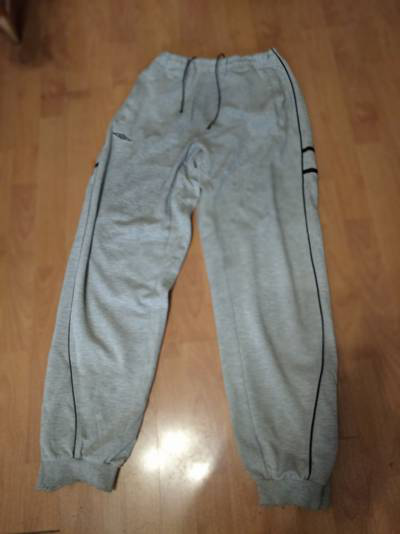

In [191]:
load_img(path)

In [194]:
img = load_img(path, target_size=(299, 299))

In [189]:
import numpy as np

In [195]:
x = np.array(img)
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [196]:
X = preprocess_input(X)

In [205]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


In [206]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [207]:
dict(zip(classes, pred[0]))

{'dress': -4.204958,
 'hat': -4.8424916,
 'longsleeve': -2.0494466,
 'outwear': -0.8125996,
 'pants': 9.268709,
 'shirt': -2.2954426,
 'shoes': -3.8766701,
 'shorts': 1.8511559,
 'skirt': -5.582153,
 't-shirt': -5.6690106}